In [8]:
from torch import nn as nn
import torch
import torch.autograd as ag
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def iRT(y,args):
    y = T_I, T_NI, T_D, L, Z_S
    args = den_T, den_L, mu, K, omega, kappa, p1, gamma, r, c4, delta_D, rho1, rho2, lamda, K_L, s, delta_L
    d_T_I = mu * T_I * (1-(T_I + T_D)/K) - (Z_p * T_I) - (Z_S * T_I)
    d_T_NI = mu * T_NI * (1-(T_NI/K)) - (Z_p * T_NI) - (Z_S * T_NI)
    d_T_D = -delta_D * T_D
    d_L  = lamda(((p1(T_I + T_NI))/(K + T_I + T_NI)) + ((p2 * T_D)/K + T_D)) * L * (1 - (L/K_L)) + s - delta_L * L
    Z_p = (omega(L/den_L))/(1 + ()))

def solution(x):
    return (-1/3)*x**3 + (1/2)*x**2 + 1

In [ ]:
#Building Neural Network Model
#base class for all neural network modules
class PINNModel(nn.Module):
    #constructor that takes in the parameters for the model
    def __init__(self, input_size: int = 1, output_size: int = 1, hidden_layers: int = 5, hidden_nodes: int = 10):
        super().__init__()
        #connecting the layers using nn.Linear(input,output)
        self.inputs = nn.Linear(input_size, hidden_nodes)
        self.model = nn.ModuleList([nn.Linear(hidden_nodes, hidden_nodes) for _ in range(hidden_layers)]) #creates list of these layers to iterate through
        self.outputs = nn.Linear(hidden_nodes, output_size)

        self.activation = nn.Tanh() # makes it nonlinear

    #applies activation to all layers in the model
    def _apply_model(self,x: torch.Tensor):
        for layer in self.model:
            x = self.activation(layer(x))
        return x

    #This is the prediction function
    def forward(self, t: torch.Tensor):
        t = self.activation(self.inputs(t))
        t = self._apply_model(t)
        t = self.outputs(t)
        return t


In [11]:
#Preparing Points for Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = torch.linspace(0, 1, 100).reshape(-1, 1) #many data points
y = solution(x).reshape(-1, 1) #analytical solution for the differential equation

#take only certain points for training
x_data = x[0:200:20]
y_data = y[0:200:20]

#move tensors to the selected device
x_data_t = x_data.detach().clone().to(device=device, dtype=torch.float32).reshape(-1, 1)
y_data_t = y_data.detach().clone().to(device=device, dtype=torch.float32).reshape(-1, 1)

#creating points for physics loss
x_physics = torch.linspace(0, 1, 100, requires_grad=True, device=device, dtype=torch.float32).reshape(-1, 1)

In [ ]:
#Training Loop
#Goals: Match the data points and satisfy the differential equation
Epochs = 20000
Length = 1e4

model = PINNModel().to(device) #create neural network
optimize = torch.optim.Adam(model.parameters(), lr=1e-3) #optimizer for the model parameters

data_loss = nn.MSELoss()

#for loop that trains the model
for epoch in range(Epochs):
    optimize.zero_grad() #reset the gradient to 0 at the start of each loop
    
    #data loss
    y_pred = model(x_data_t) #generates prediction
    loss_data = data_loss(y_pred, y_data_t) #compares prediction to the data points and calculates the loss

    #physics loss
    y_physics = model(x_physics) #generates prediction for physics points
    dy_physics = ag.grad(y_physics, x_physics, torch.ones_like(y_physics), create_graph=True)[0] #calculates derivative
    physics = dy_physics - differential_equation(x_physics) #calculates physics loss
    loss_physics = torch.mean(physics**2) #calculates mean squared error for physics loss
    total_loss = loss_data + loss_physics

    total_loss.backward() #figures out what weights caused the error
    optimize.step() #fixes the model slightly to minimize error
    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}, Total Loss: {total_loss.item()}, Data Loss: {loss_data.item()}, Physics Loss: {loss_physics.item()}")

Epoch: 0, Total Loss: 1.0804965496063232, Data Loss: 1.0459362268447876, Physics Loss: 0.034560270607471466
Epoch: 1000, Total Loss: 0.0003109454410150647, Data Loss: 9.65596200330765e-07, Physics Loss: 0.0003099798341281712
Epoch: 2000, Total Loss: 2.8947943064849824e-05, Data Loss: 1.2393255310882978e-08, Physics Loss: 2.8935550290043466e-05
Epoch: 3000, Total Loss: 1.0519482202653307e-05, Data Loss: 3.4126347969731796e-08, Physics Loss: 1.0485356142453384e-05
Epoch: 4000, Total Loss: 7.311469744308852e-06, Data Loss: 2.534672560727813e-08, Physics Loss: 7.286123036465142e-06
Epoch: 5000, Total Loss: 4.9040777412301395e-06, Data Loss: 1.83321340330167e-08, Physics Loss: 4.8857455112738535e-06
Epoch: 6000, Total Loss: 3.414224238440511e-06, Data Loss: 1.3384766184287855e-08, Physics Loss: 3.400839432288194e-06
Epoch: 7000, Total Loss: 2.5067049591598334e-06, Data Loss: 1.0219653567844489e-08, Physics Loss: 2.4964851945696864e-06
Epoch: 8000, Total Loss: 1.9513388451741775e-06, Data Lo

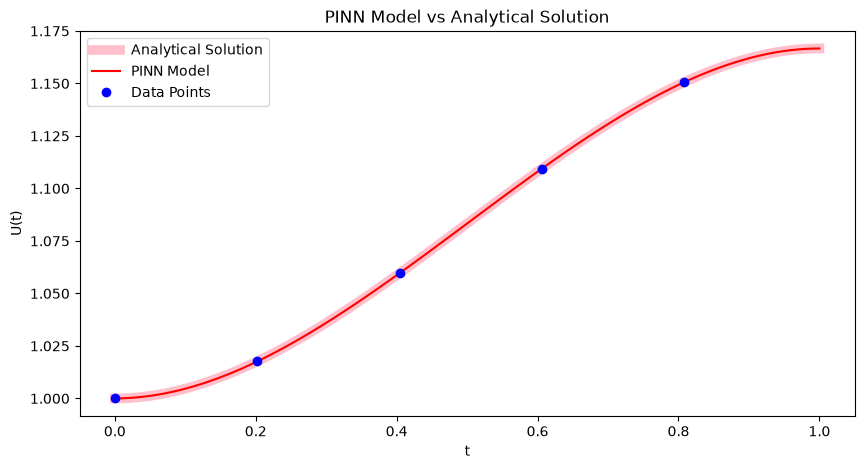

In [ ]:
#Testing the Model
model.eval()
x_test = x.detach().clone().to(device=device, dtype=torch.float32)
y_pred = model(x_test).detach().cpu().numpy().reshape(-1, 1) #get Pinn Solution curve

#Plotting the Neural Network Model vs Analytical Solution
plt.figure(figsize=(10, 5))
plt.title("PINN Model vs Analytical Solution")
plt.plot(x, y, label="Analytical Solution", color="pink", linewidth=7)
plt.xlabel("t")
plt.ylabel("U(t)")

#plotting the analytical solution
plt.plot(x, y_pred, label="PINN Model", color="red")

#plotting the training data points
plt.plot(x_data, y_data, label="Data Points", color="blue", linestyle="None", marker="o")
plt.legend()
plt.show()